In [2]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
arthurwaruwu_datasetcapstonefixx_path = kagglehub.dataset_download('arthurwaruwu/datasetcapstonefixx')

print('Data source import complete.')


Resuming download from 28311552 bytes (1296329366 bytes left)...
Resuming download from https://www.kaggle.com/api/v1/datasets/download/arthurwaruwu/datasetcapstonefixx?dataset_version_number=1 (28311552/1324640918) bytes left.


100%|██████████| 1.23G/1.23G [04:33<00:00, 4.74MB/s]

Extracting files...


Data source import complete.


In [3]:
import os
import shutil
import glob

# 1. Menentukan path direktori utama dataset gambar
dataset_path = arthurwaruwu_datasetcapstonefixx_path
print("Path direktori dataset:", dataset_path)

# 2. Melihat struktur folder di dalam dataset
print("\nDaftar folder/file di direktori utama:")
for item in os.listdir(dataset_path):
    item_path = os.path.join(dataset_path, item)
    if os.path.isdir(item_path):
        print(f"[FOLDER] {item} (isi: {len(os.listdir(item_path))} item)")
    else:
        print(f"[FILE]   {item}")

# 3. Contoh: Menyalin atau memindahkan data gambar ke direktori kerja lokal (Opsional)
# Bergantung pada apakah Anda ingin membuat folder lokal baru untuk manipulasi
local_dataset_dir = './dataset_lokal'
if not os.path.exists(local_dataset_dir):
    # Menyalin seluruh isi folder dataset kagglehub ke direktori lokal
    shutil.copytree(dataset_path, local_dataset_dir, dirs_exist_ok=True)
    print(f"\nDataset berhasil disalin ke direktori lokal: {local_dataset_dir}")
else:
    print(f"\nDirektori lokal '{local_dataset_dir}' sudah ada.")

# 4. Contoh cara meload gambar menggunakan TensorFlow/Keras (jika untuk Deep Learning)
# from tensorflow.keras.utils import image_dataset_from_directory
# 
# train_dataset = image_dataset_from_directory(
#     local_dataset_dir,
#     image_size=(224, 224),
#     batch_size=32,
#     subset="training",
#     validation_split=0.2,
#     seed=123
# )

Path direktori dataset: C:\Users\Bisma\.cache\kagglehub\datasets\arthurwaruwu\datasetcapstonefixx\versions\1

Daftar folder/file di direktori utama:
[FOLDER] Dataset-Asli (isi: 2 item)

Dataset berhasil disalin ke direktori lokal: ./dataset_lokal


# Model 1 Capstone Project : Klasifikasi Gambar Menggunakan Convolutional Neural Networks (CNN)
Notebook ini bertujuan untuk membangun dan melatih model **Convolutional Neural Network (CNN)** untuk melakukan **klasifikasi gambar organik dan anorganik**. Langkah-langkah yang dilakukan meliputi persiapan data, pembuatan model, pelatihan, dan evaluasi model. Model CNN yang dibangun akan digunakan untuk mengklasifikasikan gambar sampah rumah tangga ke dalam dua kategori utama: **organik** dan **anorganik**.

# Nama Proyek : WasteSnap
Proyek inovatif berbasis website yang bertujuan untuk membantu masyarakat Indonesia mengidentifikasi dan mengelola sampah rumah tangga secara mandiri melalui platform berbasis web.

# Tujuan Proyek:
- **Mengidentifikasi Sampah Organik dan Non-Organik**: Dengan menggunakan model CNN yang dilatih pada dataset gambar, pengguna dapat mengidentifikasi jenis sampah secara otomatis.
- **Meningkatkan Kesadaran Lingkungan**: Proyek ini bertujuan untuk meningkatkan kesadaran masyarakat mengenai pengelolaan sampah dan pentingnya pemisahan sampah organik dan non-organik untuk mendukung program daur ulang.
- **Pengelolaan Sampah yang Lebih Efisien**: Dengan aplikasi ini, masyarakat dapat memisahkan sampah mereka dengan lebih mudah dan efisien, serta membantu mengurangi dampak lingkungan yang disebabkan oleh pembuangan sampah sembarangan.

Melalui proyek ini, teknologi klasifikasi gambar diharapkan dapat membantu masyarakat Indonesia dalam pengelolaan sampah rumah tangga secara lebih mandiri dan ramah lingkungan.

# Anggota Tim Machine Learning
## ID tim : CC25-CF318.
Arthur Setiawan Waruwu | MC319D5Y2042 | Universitas Sumatera Utara | \
Sakifa Indira Putri | MC319D5X2380 | Universitas Sumatera Utara | \
Diva Anggreini Harahap | MC319D5X2329 | Universitas Sumatera Utara |

# Penjelasan Dataset
Dataset ini berisi gambar-gambar sampah rumah tangga yang sudah kami kelompokkan dalam folder yang sesuai dengan jenisnya. Dataset ini memiliki 13.8k gambar, yang masing-masing kami kumpulkan secara mandiri dari berbagai sumber, seperti Kaggle, Google Images, Pinterest, dan sumber-sumber lainnya. Berikut adalah kategori-kategori yang terdapat dalam dataset ini:
- Buah
- Cangkang Telur
- Elektronik
- Kaca
- Kain
- Kardus
- Karet
- Kayu
- Kertas
- Kotoran Hewan
- Logam
- Plastik
- Sayuran
- Sepatu
- Sisa Teh dan Kopi
- Sisa Makanan
- Styrofoam

# 1. Import Libraries
Langkah pertama yang akan kita lakukan adalah mengimpor berbagai libraries yang menyediakan fungsi-fungsi yang kita perlukan.

In [4]:
# Install tensorflow menggunakan perintah pip
!pip install tensorflow opencv-python Pillow tensorflowjs

  Using cached packaging-20.9-py2.py3-none-any.whl.metadata (13 kB)
Using cached packaging-20.9-py2.py3-none-any.whl (40 kB)
  Attempting uninstall: packaging
    Found existing installation: packaging 25.0
    Uninstalling packaging-25.0:
      Successfully uninstalled packaging-25.0


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipykernel 6.30.1 requires packaging>=22, but you have packaging 20.9 which is incompatible.
google-cloud-bigquery 3.40.1 requires packaging>=24.2.0, but you have packaging 20.9 which is incompatible.
pytesseract 0.3.13 requires packaging>=21.3, but you have packaging 20.9 which is incompatible.

[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
# Import Library yang diperlukan
# Untuk pengolahan citra
import cv2
from PIL import Image, ImageEnhance

# Untuk operasi array dan manipulasi data
import numpy as np
import pandas as pd
import os
import random
import shutil

# Untuk visualisasi
import matplotlib.pyplot as plt  # Matplotlib

# Untuk machine learning / deep learning
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

# Catatan: tensorflowjs dihapus dari sini karena menyebabkan error NumPy 2.x
# Nanti bisa di-import atau dijalankan via terminal saat Anda ingin export model ke web.
print("Library berhasil di-import tanpa error!")

Library berhasil di-import tanpa error!


# 2. Data Preparation
Persiapan data untuk klasifikasi gambar melibatkan pengolahan gambar sehingga dapat dimasukkan ke dalam model CNN.

## Data Loading
Pada bagian ini, kita akan memuat dataset gambar yang akan digunakan untuk train dan validation model. Dataset telah diupload ke kaggle dan akan dimuat langsung ke dalam notebook. Sebelum itu, kita akan menyalin dataset dari direktori `/kaggle/input/` yang sifatnya itu read-only ke direktori working `/kaggle/working/` yang dapat ditulis, jadi kita bisa melakukan berbagai operasi tanpa terbatas oleh izin akses read-only.

In [12]:
import os
import shutil

# Path sumber dataset di komputer lokal Anda
dataset_dir = r'C:\Users\Bisma\Downloads\dataset_lokal'

# Path folder kerja lokal (disimpan di direktori tempat script/Jupyter Notebook Anda berjalan)
working_dir = './dataset-capstone'

if not os.path.exists(dataset_dir):
    print(f"Direktori sumber {dataset_dir} tidak ditemukan!")
else:
    if os.path.exists(working_dir):
        print(f"Folder {working_dir} sudah ada, sedang dihapus...")
        shutil.rmtree(working_dir)

    # Menyalin dataset dari folder Downloads lokal ke folder kerja proyek
    try:
        shutil.copytree(dataset_dir, working_dir)
        print(f"Dataset berhasil disalin ke: {working_dir}")
    except Exception as e:
        print(f"Gagal menyalin dataset: {e}")

Dataset berhasil disalin ke: ./dataset-capstone


In [14]:
import os

working_dir = './dataset-capstone'
print("Isi folder working_dir:", os.path.isdir(working_dir) and os.listdir(working_dir))

Isi folder working_dir: ['Dataset-Asli']


In [15]:
# Tambahkan sub-folder 'Dataset-Asli' jika struktur aslinya seperti itu
base_dir_fixed = os.path.join(working_dir, 'Dataset-Asli')

main_folders = ['Anorganik', 'Organik']
count_images_per_class_in_main_folders(base_dir_fixed, main_folders)


Folder utama 'Anorganik' memiliki 10 kelas:
  Kelas 'Elektronik' : 517 gambar
  Kelas 'Kaca' : 750 gambar
  Kelas 'Kain' : 450 gambar
  Kelas 'Kardus' : 580 gambar
  Kelas 'Karet' : 533 gambar
  Kelas 'Kertas' : 600 gambar
  Kelas 'Logam' : 598 gambar
  Kelas 'Plastik' : 717 gambar
  Kelas 'Sepatu' : 508 gambar
  Kelas 'Styrofoam' : 457 gambar

Folder utama 'Organik' memiliki 7 kelas:
  Kelas 'Cangkang Telur' : 660 gambar
  Kelas 'Kayu' : 533 gambar
  Kelas 'Kotoran Hewan' : 496 gambar
  Kelas 'Sisa Buah' : 795 gambar
  Kelas 'Sisa makanan' : 788 gambar
  Kelas 'Sisa Teh Kopi' : 586 gambar
  Kelas 'Tumbuhan' : 791 gambar

Total seluruh gambar di semua kelas: 10359


In [17]:
# menghitung total gambar di dataset
def count_images_per_class_in_main_folders(base_dir, main_folders):
    total_images = 0

    for main_folder in main_folders:
        main_path = os.path.join(base_dir, main_folder)
        if not os.path.isdir(main_path):
            print(f"Folder {main_folder} tidak ditemukan di {base_dir}")
            continue

        kelas_list = [k for k in os.listdir(main_path) if os.path.isdir(os.path.join(main_path, k))]
        print(f"\nFolder utama '{main_folder}' memiliki {len(kelas_list)} kelas:")

        for kelas in kelas_list:
            kelas_path = os.path.join(main_path, kelas)
            images = [f for f in os.listdir(kelas_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
            jumlah = len(images)
            print(f"  Kelas '{kelas}' : {jumlah} gambar")
            total_images += jumlah

    print(f"\nTotal seluruh gambar di semua kelas: {total_images}")

# Perbaikan: Menggunakan base_dir_fixed yang mencakup sub-folder 'Dataset-Asli'
base_dir_fixed = os.path.join(working_dir, 'Dataset-Asli')
main_folders = ['Anorganik', 'Organik']

count_images_per_class_in_main_folders(base_dir_fixed, main_folders)


Folder utama 'Anorganik' memiliki 10 kelas:
  Kelas 'Elektronik' : 517 gambar
  Kelas 'Kaca' : 750 gambar
  Kelas 'Kain' : 450 gambar
  Kelas 'Kardus' : 580 gambar
  Kelas 'Karet' : 533 gambar
  Kelas 'Kertas' : 600 gambar
  Kelas 'Logam' : 598 gambar
  Kelas 'Plastik' : 717 gambar
  Kelas 'Sepatu' : 508 gambar
  Kelas 'Styrofoam' : 457 gambar

Folder utama 'Organik' memiliki 7 kelas:
  Kelas 'Cangkang Telur' : 660 gambar
  Kelas 'Kayu' : 533 gambar
  Kelas 'Kotoran Hewan' : 496 gambar
  Kelas 'Sisa Buah' : 795 gambar
  Kelas 'Sisa makanan' : 788 gambar
  Kelas 'Sisa Teh Kopi' : 586 gambar
  Kelas 'Tumbuhan' : 791 gambar

Total seluruh gambar di semua kelas: 10359


In [19]:
# Memeriksa ekstensi gambar yang valid
valid_extensions = {'.jpg', '.jpeg', '.png'}

def cek_ekstensi_tidak_valid(base_dir, main_folders):
    invalid_files = []

    for main_folder in main_folders:
        main_path = os.path.join(base_dir, main_folder)
        if not os.path.isdir(main_path):
            print(f"Folder {main_folder} tidak ditemukan di {base_dir}")
            continue

        kelas_list = [k for k in os.listdir(main_path) if os.path.isdir(os.path.join(main_path, k))]

        for kelas in kelas_list:
            kelas_path = os.path.join(main_path, kelas)
            files = os.listdir(kelas_path)

            for f in files:
                ext = os.path.splitext(f)[1].lower()
                if ext not in valid_extensions:
                    invalid_files.append(os.path.join(main_folder, kelas, f))

    if invalid_files:
        print("File dengan ekstensi tidak valid ditemukan:")
        for file_path in invalid_files:
            print(f" - {file_path}")
        print(f"\nTotal file dengan ekstensi tidak valid: {len(invalid_files)}")
    else:
        print("Semua file memiliki ekstensi gambar yang valid.")
        print("Total file tidak valid: 0")

# Perbaikan: Gunakan base_dir_fixed yang mengarah langsung ke dalam folder 'Dataset-Asli'
base_dir_fixed = os.path.join(working_dir, 'Dataset-Asli')
main_folders = ['Anorganik', 'Organik']

# Panggil fungsi dengan path yang sudah benar
cek_ekstensi_tidak_valid(base_dir_fixed, main_folders)

File dengan ekstensi tidak valid ditemukan:
 - Anorganik\Elektronik\cfl-waste-recycling.gif
 - Anorganik\Karet\Ban Luar Tire Kenda Flame 24x2_125 K1008A 24 x 2.125
 - Anorganik\Karet\MaxPower Rubber Inflatable Tubeless Rib Tread Wheelbarrow Tire 300 lbs_ Capacity 13 Dia. in
 - Anorganik\Karet\Sasaki M-207BRM Meteor 18_5cm - COG-Cobalt Green _ 18.5cm
 - Anorganik\Karet\Sasaki M-20A Gym Star 18_5cm - FFR-Fresh Red _ 18.5cm
 - Anorganik\Karet\Sasaki M-20A Gym Star 18_5cm - FRO-Fresh Orange _ 18.5cm
 - Anorganik\Karet\Sasaki M-20A Gym Star 18_5cm - RRK-Lilac _ 18.5cm
 - Anorganik\Karet\Unique Bargains Solid Rubber Strips Neoprene Sheets Rolls 1_8_T x 1_97_W x 157.48_L, DIY Rubber Gasket Sealing Padding - Walmart.ca
 - Anorganik\Styrofoam\Bagasse 3 Compartment Meal Box 9_25inch _ 23.5cm
 - Anorganik\Styrofoam\Bagasse Clamshell Lunch Box 18_2 x 13.6 x 4.6cm
 - Anorganik\Styrofoam\Isolierte Lunchbox in Weiß aus XPS - 185 x 155 x 75mm - ca_ 2100ml - 1 Karton (= 500 Stk.)
 - Organik\Cangkang Te

Melihat dari output di atas, tampaknya masih ada sedikit gambar dengan ekstensi .webp yang tidak valid. Oleh karena itu, kita akan menghapus gambar-gambar ini terlebih dahulu sebelum membagi dataset.

In [21]:
# Menghapus gambar yang tidak valid
def hapus_file_tidak_valid(base_dir, main_folders):
    deleted_files = []

    for main_folder in main_folders:
        main_path = os.path.join(base_dir, main_folder)
        if not os.path.isdir(main_path):
            print(f"Folder {main_folder} tidak ditemukan di {base_dir}")
            continue

        kelas_list = [k for k in os.listdir(main_path) if os.path.isdir(os.path.join(main_path, k))]

        for kelas in kelas_list:
            kelas_path = os.path.join(main_path, kelas)
            files = os.listdir(kelas_path)

            for f in files:
                ext = os.path.splitext(f)[1].lower()
                if ext not in valid_extensions:
                    file_path = os.path.join(kelas_path, f)
                    try:
                        os.remove(file_path)
                        deleted_files.append(os.path.join(main_folder, kelas, f))
                    except Exception as e:
                        print(f"Gagal menghapus {file_path}: {e}")

    if deleted_files:
        print("Berhasil menghapus file berikut dengan ekstensi tidak valid:")
        for file_path in deleted_files:
            print(f" - {file_path}")
        print(f"\nTotal file yang dihapus: {len(deleted_files)}")
    else:
        print("Tidak ditemukan file dengan ekstensi tidak valid untuk dihapus.")

# Perbaikan: Menggunakan base_dir_fixed yang mengarah ke dalam folder 'Dataset-Asli'
base_dir_fixed = os.path.join(working_dir, 'Dataset-Asli')
main_folders = ['Anorganik', 'Organik']

# Panggil fungsi dengan path yang benar
hapus_file_tidak_valid(base_dir_fixed, main_folders)

Berhasil menghapus file berikut dengan ekstensi tidak valid:
 - Anorganik\Elektronik\cfl-waste-recycling.gif
 - Anorganik\Karet\Ban Luar Tire Kenda Flame 24x2_125 K1008A 24 x 2.125
 - Anorganik\Karet\MaxPower Rubber Inflatable Tubeless Rib Tread Wheelbarrow Tire 300 lbs_ Capacity 13 Dia. in
 - Anorganik\Karet\Sasaki M-207BRM Meteor 18_5cm - COG-Cobalt Green _ 18.5cm
 - Anorganik\Karet\Sasaki M-20A Gym Star 18_5cm - FFR-Fresh Red _ 18.5cm
 - Anorganik\Karet\Sasaki M-20A Gym Star 18_5cm - FRO-Fresh Orange _ 18.5cm
 - Anorganik\Karet\Sasaki M-20A Gym Star 18_5cm - RRK-Lilac _ 18.5cm
 - Anorganik\Karet\Unique Bargains Solid Rubber Strips Neoprene Sheets Rolls 1_8_T x 1_97_W x 157.48_L, DIY Rubber Gasket Sealing Padding - Walmart.ca
 - Anorganik\Styrofoam\Bagasse 3 Compartment Meal Box 9_25inch _ 23.5cm
 - Anorganik\Styrofoam\Bagasse Clamshell Lunch Box 18_2 x 13.6 x 4.6cm
 - Anorganik\Styrofoam\Isolierte Lunchbox in Weiß aus XPS - 185 x 155 x 75mm - ca_ 2100ml - 1 Karton (= 500 Stk.)
 - Or

Pada tahap ini, telah dilakukan pengecekan dan penghapusan terhadap gambar-gambar yang tidak valid dalam dataset. Berdasarkan hasil pemeriksaan, sebanyak **34 gambar** dengan ekstensi tidak valid telah dihapus.

In [24]:
import os

# 1. Definisikan kembali path kerja dan ekstensi valid
working_dir = './dataset-capstone'
base_dir_fixed = os.path.join(working_dir, 'Dataset-Asli')
main_folders = ['Anorganik', 'Organik']
valid_extensions = {'.jpg', '.jpeg', '.png'}

# 2. Definisikan fungsi pengecekan
def cek_ekstensi_tidak_valid(base_dir, main_folders):
    invalid_files = []

    for main_folder in main_folders:
        main_path = os.path.join(base_dir, main_folder)
        if not os.path.isdir(main_path):
            print(f"Peringatan: Folder {main_folder} tidak ditemukan di {base_dir}")
            continue

        kelas_list = [k for k in os.listdir(main_path) if os.path.isdir(os.path.join(main_path, k))]

        for kelas in kelas_list:
            kelas_path = os.path.join(main_path, kelas)
            files = os.listdir(kelas_path)

            for f in files:
                ext = os.path.splitext(f)[1].lower()
                if ext not in valid_extensions:
                    invalid_files.append(os.path.join(main_folder, kelas, f))

    if invalid_files:
        print("Masih terdapat file dengan ekstensi tidak valid:")
        for file_path in invalid_files:
            print(f" - {file_path}")
        print(f"Total file tidak valid: {len(invalid_files)}")
    else:
        print("AMAN: Tidak ditemukan file dengan ekstensi tidak valid lagi.")

# 3. Jalankan fungsi
cek_ekstensi_tidak_valid(base_dir_fixed, main_folders)

AMAN: Tidak ditemukan file dengan ekstensi tidak valid lagi.


Nah, bisa dipastikan bahwa seluruh gambar dalam dataset ini sudah **valid** dan siap digunakan untuk pelatihan model.


--- Contoh gambar dari kelas di folder 'Anorganik' ---
Gagal membaca gambar ./dataset-capstone\Dataset-Asli\Anorganik\Karet\$10 ix ice pop molds made of durable BPA-free….jpeg


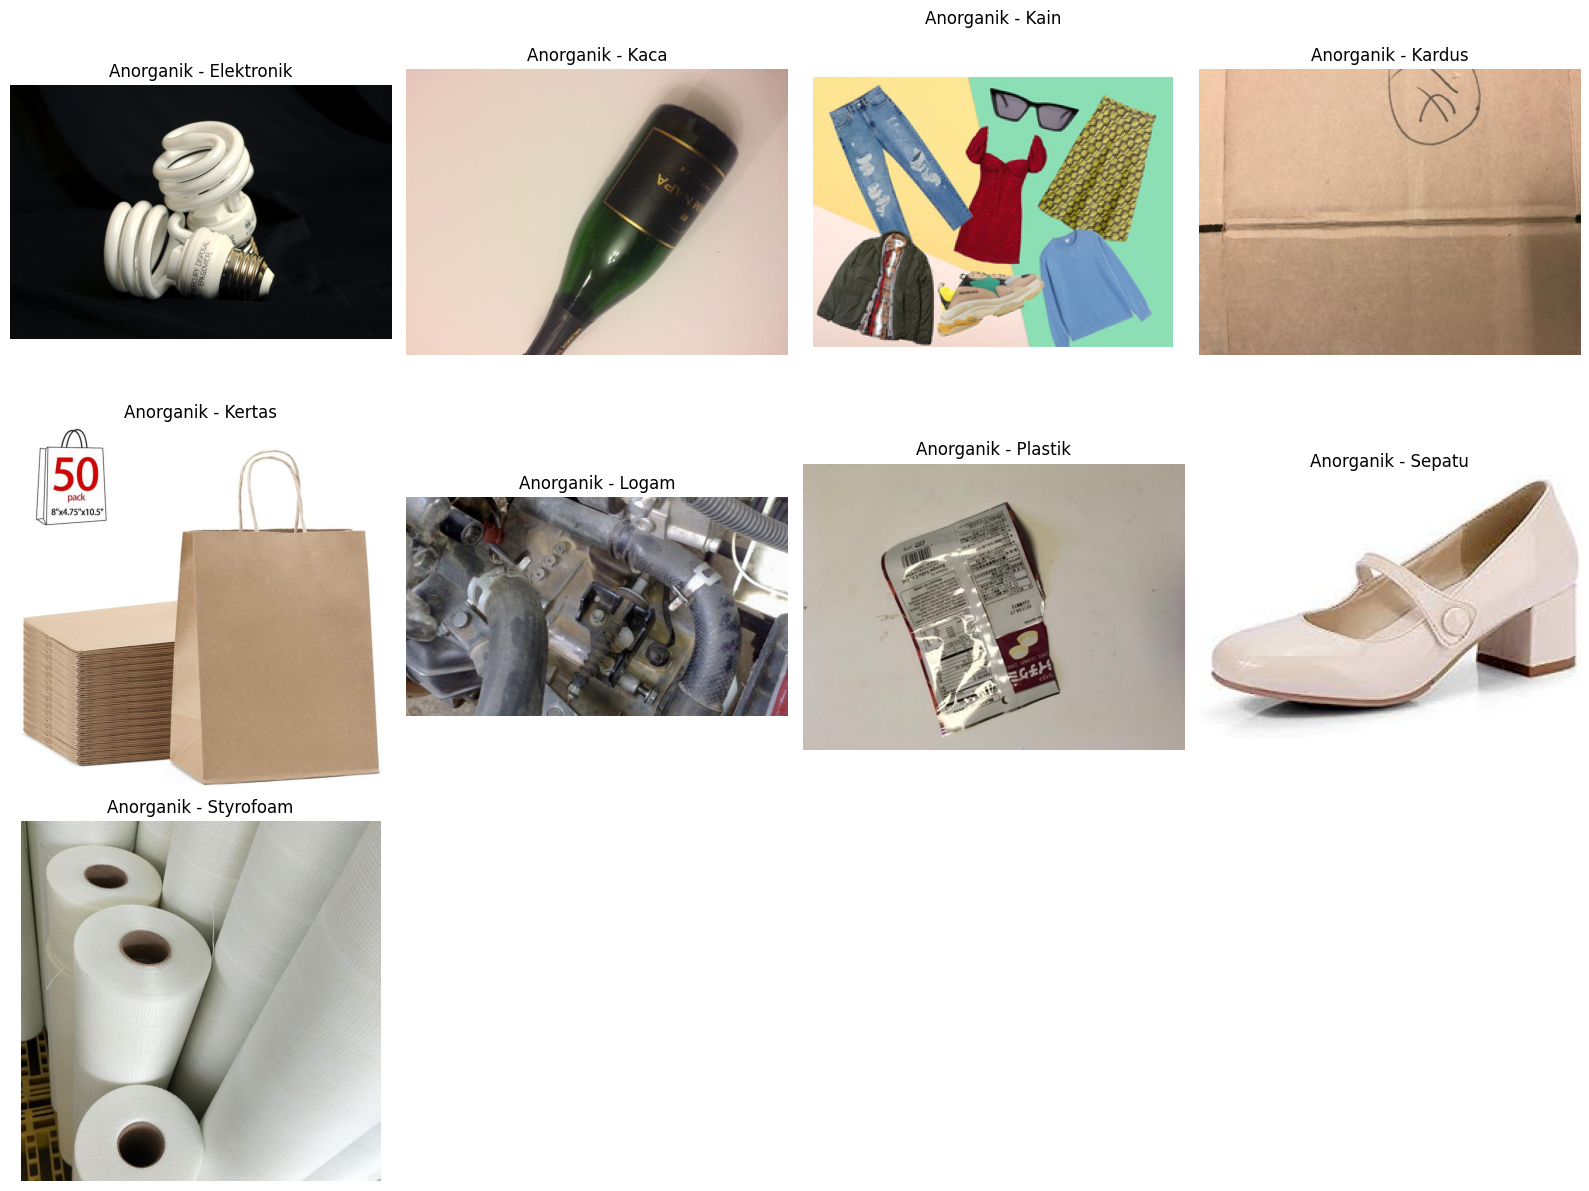


--- Contoh gambar dari kelas di folder 'Organik' ---


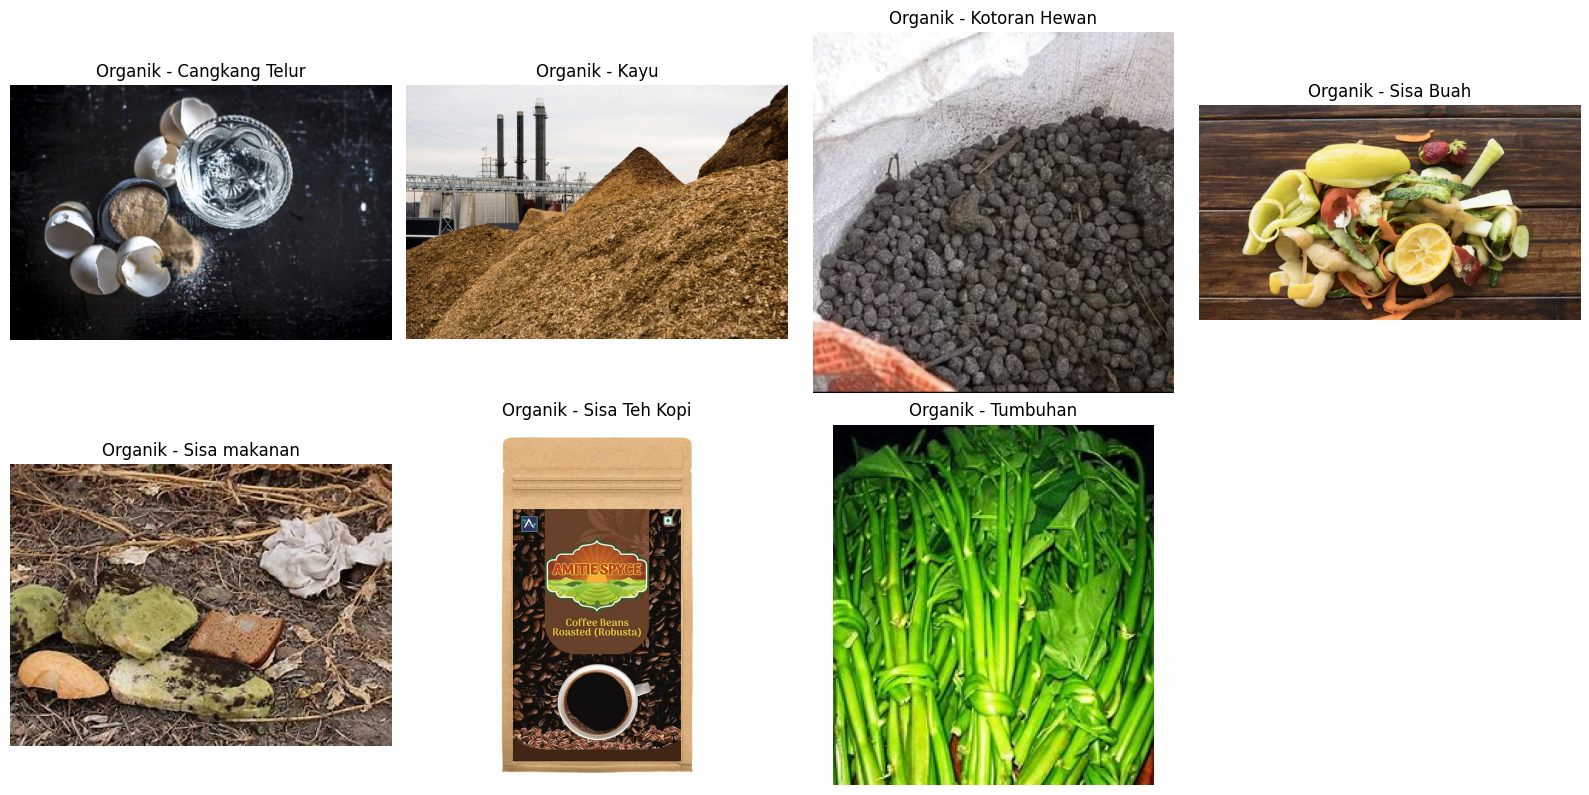

In [26]:
import os
import cv2
import matplotlib.pyplot as plt

def show_sample_images(base_dir, main_folders):
    for main_folder in main_folders:
        main_path = os.path.join(base_dir, main_folder)
        if not os.path.isdir(main_path):
            print(f"Folder {main_folder} tidak ditemukan.")
            continue

        print(f"\n--- Contoh gambar dari kelas di folder '{main_folder}' ---")
        kelas_list = [k for k in os.listdir(main_path) if os.path.isdir(os.path.join(main_path, k))]

        images = []
        titles = []

        for kelas in kelas_list:
            kelas_path = os.path.join(main_path, kelas)
            files = [f for f in os.listdir(kelas_path) if os.path.splitext(f)[1].lower() in valid_extensions]

            if len(files) == 0:
                print(f"Tidak ada gambar valid di kelas '{kelas}'")
                continue

            contoh_gambar_path = os.path.join(kelas_path, files[0])
            img = cv2.imread(contoh_gambar_path)
            if img is None:
                print(f"Gagal membaca gambar {contoh_gambar_path}")
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            images.append(img)
            titles.append(f"{main_folder} - {kelas}")

        if len(images) == 0:
            print(f"Tidak ada gambar valid untuk ditampilkan di folder '{main_folder}'.")
            continue

        cols = 4
        total = len(images)
        rows = (total + cols - 1) // cols

        fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
        
        # Penanganan jika axes berupa array 2D atau 1D atau single object
        if rows == 1 and cols == 1:
            axes = [axes]
        else:
            axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]

        for i in range(len(axes)):
            if i < total:
                axes[i].imshow(images[i])
                axes[i].set_title(titles[i], fontsize=12)
                axes[i].axis('off')
            else:
                axes[i].axis('off')

        plt.tight_layout()
        plt.show()

# Perbaikan: Gunakan base_dir_fixed yang mengarah langsung ke dalam folder 'Dataset-Asli'
base_dir_fixed = os.path.join(working_dir, 'Dataset-Asli')
main_folders = ['Anorganik', 'Organik']

# Panggil fungsi dengan path yang benar
show_sample_images(base_dir_fixed, main_folders)

## Split Dataset

In [27]:
# Split data 80% Train, 10% Test, 10% Val (Versi Komputer Lokal)

# Gunakan base_dir_fixed dan tentukan output folder di direktori lokal Anda
base_dir_fixed = os.path.join(working_dir, 'Dataset-Asli')
output_dir = './Dataset-Split'

main_folders = ['Anorganik', 'Organik']
splits = {
    'Train': 0.8,
    'Test': 0.1,
    'Val': 0.1
}

valid_extensions = ('.jpg', '.jpeg', '.png')

random.seed(42)

def create_dir_if_not_exist(path):
    if not os.path.exists(path):
        os.makedirs(path)

def split_dataset(base_dir, output_dir, main_folders, splits):
    # Membuat struktur folder tujuan (Train, Test, Val -> Anorganik/Organik -> Nama Kelas)
    for split_name in splits.keys():
        for main_folder in main_folders:
            main_path = os.path.join(base_dir, main_folder)
            if not os.path.isdir(main_path):
                continue
            
            # Mendapatkan list kelas dari folder utama
            kelas_list = [k for k in os.listdir(main_path) if os.path.isdir(os.path.join(main_path, k))]
            for kelas in kelas_list:
                create_dir_if_not_exist(os.path.join(output_dir, split_name, main_folder, kelas))

    for main_folder in main_folders:
        main_path = os.path.join(base_dir, main_folder)
        if not os.path.isdir(main_path):
            print(f"Folder {main_folder} tidak ditemukan, skip.")
            continue

        kelas_list = [k for k in os.listdir(main_path) if os.path.isdir(os.path.join(main_path, k))]

        for kelas in kelas_list:
            kelas_path = os.path.join(main_path, kelas)
            files = [f for f in os.listdir(kelas_path) if f.lower().endswith(valid_extensions)]

            random.shuffle(files)

            n_total = len(files)
            n_train = int(n_total * splits['Train'])
            n_test = int(n_total * splits['Test'])
            n_val = n_total - n_train - n_test

            train_files = files[:n_train]
            test_files = files[n_train:n_train+n_test]
            val_files = files[n_train+n_test:]

            for split_name, file_list in zip(['Train', 'Test', 'Val'], [train_files, test_files, val_files]):
                kelas_output_path = os.path.join(output_dir, split_name, main_folder, kelas)
                create_dir_if_not_exist(kelas_output_path)

                for file_name in file_list:
                    src_path = os.path.join(kelas_path, file_name)
                    dst_path = os.path.join(kelas_output_path, file_name)
                    shutil.copy2(src_path, dst_path)

            print(f"{main_folder}/{kelas}: total={n_total}, train={len(train_files)}, test={len(test_files)}, val={len(val_files)}")

# Memanggil fungsi split dataset
split_dataset(base_dir_fixed, output_dir, main_folders, splits)
print("\nProses splitting dataset berhasil diselesaikan!")

Anorganik/Elektronik: total=517, train=413, test=51, val=53
Anorganik/Kaca: total=750, train=600, test=75, val=75
Anorganik/Kain: total=450, train=360, test=45, val=45
Anorganik/Kardus: total=580, train=464, test=58, val=58
Anorganik/Karet: total=533, train=426, test=53, val=54
Anorganik/Kertas: total=600, train=480, test=60, val=60
Anorganik/Logam: total=598, train=478, test=59, val=61
Anorganik/Plastik: total=717, train=573, test=71, val=73
Anorganik/Sepatu: total=508, train=406, test=50, val=52
Anorganik/Styrofoam: total=457, train=365, test=45, val=47
Organik/Cangkang Telur: total=660, train=528, test=66, val=66
Organik/Kayu: total=533, train=426, test=53, val=54
Organik/Kotoran Hewan: total=496, train=396, test=49, val=51
Organik/Sisa Buah: total=795, train=636, test=79, val=80
Organik/Sisa makanan: total=788, train=630, test=78, val=80
Organik/Sisa Teh Kopi: total=586, train=468, test=58, val=60
Organik/Tumbuhan: total=791, train=632, test=79, val=80

Proses splitting dataset ber

Dapat dilihat output diatas merupakan hasil split data dengan rasio Train 80, Test 10, dan Val 10

In [28]:
# Menghitung jumlah gambar train, val, dan test
def count_images_in_split(output_dir, main_folders, splits):
    print("\nTotal jumlah gambar per split:")
    for split_name in splits.keys():
        total_count = 0
        split_path = os.path.join(output_dir, split_name)
        for main_folder in main_folders:
            main_path = os.path.join(split_path, main_folder)
            if not os.path.isdir(main_path):
                continue
            kelas_list = [k for k in os.listdir(main_path) if os.path.isdir(os.path.join(main_path, k))]
            for kelas in kelas_list:
                kelas_path = os.path.join(main_path, kelas)
                files = [f for f in os.listdir(kelas_path) if f.lower().endswith(valid_extensions)]
                total_count += len(files)
        print(f"{split_name}: {total_count} gambar")

# Memanggil fungsi pengecekan jumlah gambar split
count_images_in_split(output_dir, main_folders, splits)


Total jumlah gambar per split:
Train: 8281 gambar
Test: 1029 gambar
Val: 1049 gambar


In [30]:
!pip install scikit-image

  Using cached packaging-26.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached lazy_loader-0.5-py3-none-any.whl.metadata (5.9 kB)
   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
    --------------------------------------- 0.3/11.9 MB ? eta -:--:--
   ---- ----------------------------------- 1.3/11.9 MB 5.3 MB/s eta 0:00:03
   --------- ------------------------------ 2.9/11.9 MB 6.1 MB/s eta 0:00:02
   ------------- -------------------------- 3.9/11.9 MB 5.9 MB/s eta 0:00:02
   ----------------- ---------------------- 5.2/11.9 MB 6.0 MB/s eta 0:00:02
   ---------------------- ----------------- 6.6/11.9 MB 6.2 MB/s eta 0:00:01
   ---------------------- ----------------- 6.8/11.9 MB 5.5 MB/s eta 0:00:01
   ----------------------- ---------------- 7.1/11.9 MB 4.8 MB/s eta 0:00:02
   ----------------------------- ---------- 8.7/11.9 MB 5.1 MB/s eta 0:00:01
   ---------------------------------- ----- 10.2/11.9 MB 5.4 MB/s eta 0:00:01
   --------------------------------

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mlflow-skinny 3.8.0 requires packaging<26, but you have packaging 26.2 which is incompatible.
mlflow-tracing 3.8.0 requires packaging<26, but you have packaging 26.2 which is incompatible.
streamlit 1.50.0 requires packaging<26,>=20, but you have packaging 26.2 which is incompatible.
tensorflowjs 3.18.0 requires packaging~=20.9, but you have packaging 26.2 which is incompatible.

[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Data Preprocessing

In [31]:
# Augmentasi, Resize dan Normalisasi untuk folder train
from skimage import exposure

# custom contrast (opsional)
def contrast_stretching(img):
    p2, p98 = np.percentile(img, (2, 98))
    img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))
    return img_rescale

# path folder train setelah split
train_folder = os.path.join(output_dir, 'Train')

train_datagen = ImageDataGenerator(
    rescale=1./255,             # normalisasi
    rotation_range=30,          # rotasi
    width_shift_range=0.2,      # translasi horizontal
    height_shift_range=0.2,     # translasi vertikal
    shear_range=0.3,            # shearing
    zoom_range=0.3,             # zoom
    horizontal_flip=True,       # flip horizontal
    fill_mode='nearest',
    channel_shift_range=50,     # perpindahan warna channel
    # preprocessing_function=contrast_stretching  # aktifkan jika ingin pakai contrast stretching
)

train_generator = train_datagen.flow_from_directory(
    train_folder,
    target_size=(224, 224),     # resize gambar ke ukuran 224x224
    batch_size=32,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=True,
    seed=42
)

print("Folder 'train' berhasil diproses dengan ImageDataGenerator.")
print(f"Jumlah folder/kelas utama: {len(train_generator.class_indices)}")
print(f"Daftar kelas terdeteksi: {list(train_generator.class_indices.keys())}")

Found 8281 images belonging to 2 classes.
Folder 'train' berhasil diproses dengan ImageDataGenerator.
Jumlah folder/kelas utama: 2
Daftar kelas terdeteksi: ['Anorganik', 'Organik']


In [32]:
# Normalisasi untuk folder Test dan Validation
test_folder = os.path.join(output_dir, 'Test')
val_folder = os.path.join(output_dir, 'Val')

val_test_datagen = ImageDataGenerator(rescale=1./255)

val_generator = val_test_datagen.flow_from_directory(
    val_folder,
    batch_size=32,
    target_size=(224, 224),  # ini juga harus sama
    class_mode='categorical',
    shuffle=False,
    color_mode= 'rgb'
)

test_generator = val_test_datagen.flow_from_directory(
    test_folder,
    batch_size=32,
    target_size=(224, 224),  # ini juga harus sama
    class_mode='categorical',
    shuffle=False,
    color_mode= 'rgb'
)

# Output informasi sukses untuk validation
print("Folder 'validation' berhasil diproses dengan ImageDataGenerator.")
print(f"Jumlah kelas (val): {len(val_generator.class_indices)}")

# Output informasi sukses untuk test
print("Folder 'test' berhasil diproses dengan ImageDataGenerator.")
print(f"Jumlah kelas (test): {len(test_generator.class_indices)}")

Found 1049 images belonging to 2 classes.
Found 1029 images belonging to 2 classes.
Folder 'validation' berhasil diproses dengan ImageDataGenerator.
Jumlah kelas (val): 2
Folder 'test' berhasil diproses dengan ImageDataGenerator.
Jumlah kelas (test): 2


In [33]:
print(f"Mapping kelas: {train_generator.class_indices}")
print(f"Mapping kelas (val): {val_generator.class_indices}")
print(f"Mapping kelas (test): {test_generator.class_indices}")

Mapping kelas: {'Anorganik': 0, 'Organik': 1}
Mapping kelas (val): {'Anorganik': 0, 'Organik': 1}
Mapping kelas (test): {'Anorganik': 0, 'Organik': 1}


# **3. Modelling**

In [34]:
import numpy as np
from collections import Counter

# Menghitung jumlah data per label
label_counts = Counter(train_generator.classes)

# Mengambil mapping label
label_map = train_generator.class_indices
label_map_inv = {v: k for k, v in label_map.items()}

# Menampilkan hasil
for label_index, count in label_counts.items():
    print(f"{label_map_inv[label_index]}: {count} gambar")

Anorganik: 4565 gambar
Organik: 3716 gambar


In [35]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Ambil semua label dari generator
train_labels = train_generator.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights_dict = dict(enumerate(class_weights))
print("Class weights:", class_weights_dict)

Class weights: {0: np.float64(0.9070098576122673), 1: np.float64(1.1142357373519913)}


In [36]:
from tensorflow.keras.applications import MobileNetV2

# Input layer
input_tensor = Input(shape=(224, 224, 3),name='gambar_input')

# Base model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=input_tensor)
print("Jumlah total layer:", len(base_model.layers))

# Set semua layer dapat dilatih terlebih dahulu
base_model.trainable = True

# Bekukan semua layer kecuali 60 terakhir
for layer in base_model.layers[:-60]:
    layer.trainable = False

# Tambahkan custom layers di atas base model
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
output_tensor = Dense(len(train_generator.class_indices), activation='softmax',name='prediksi_output')(x)

# Buat model final
model = Model(inputs=input_tensor, outputs=output_tensor)

# Lihat arsitektur model
model.summary()

C:\Users\Bisma\AppData\Local\Temp\ipykernel_4040\1065130225.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_tensor=input_tensor)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Jumlah total layer: 154


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ gambar_input        │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ gambar_input[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 2,119,938 (8.09 MB)

 Non-trainable params: 302,272 (1.15 MB)

In [ ]:

# Callback ReduceLROnPlateau
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1,
    min_lr=1e-6
)

# Callback EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,             # jika val_loss tidak membaik selama 5 epoch, training stop
    restore_best_weights=True,
    verbose=1
)

# Compile dan fit dengan epochs 50 dan callbacks
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    callbacks=[reduce_lr, early_stop],

        

)


c:\Users\Bisma\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8317 - loss: 0.3698

c:\Users\Bisma\AppData\Local\Programs\Python\Python313\Lib\site-packages\PIL\Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


259/259 ━━━━━━━━━━━━━━━━━━━━ 668s 3s/step - accuracy: 0.8959 - loss: 0.2618 - val_accuracy: 0.9409 - val_loss: 0.1702 - learning_rate: 1.0000e-04
Epoch 2/20
259/259 ━━━━━━━━━━━━━━━━━━━━ 515s 2s/step - accuracy: 0.9376 - loss: 0.1616 - val_accuracy: 0.9342 - val_loss: 0.2149 - learning_rate: 1.0000e-04
Epoch 3/20
259/259 ━━━━━━━━━━━━━━━━━━━━ 419s 2s/step - accuracy: 0.9574 - loss: 0.1145 - val_accuracy: 0.9571 - val_loss: 0.1067 - learning_rate: 1.0000e-04
Epoch 4/20
259/259 ━━━━━━━━━━━━━━━━━━━━ 574s 2s/step - accuracy: 0.9599 - loss: 0.1097 - val_accuracy: 0.9657 - val_loss: 0.0977 - learning_rate: 1.0000e-04
Epoch 5/20
259/259 ━━━━━━━━━━━━━━━━━━━━ 667s 3s/step - accuracy: 0.9732 - loss: 0.0741 - val_accuracy: 0.9533 - val_loss: 0.1443 - learning_rate: 1.0000e-04
Epoch 6/20
259/259 ━━━━━━━━━━━━━━━━━━━━ 606s 2s/step - accuracy: 0.9775 - loss: 0.0609 - val_accuracy: 0.9561 - val_loss: 0.1491 - learning_rate: 1.0000e-04
Epoch 7/20
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9781

# **4. Evaluasi Model dan Visualisasi**

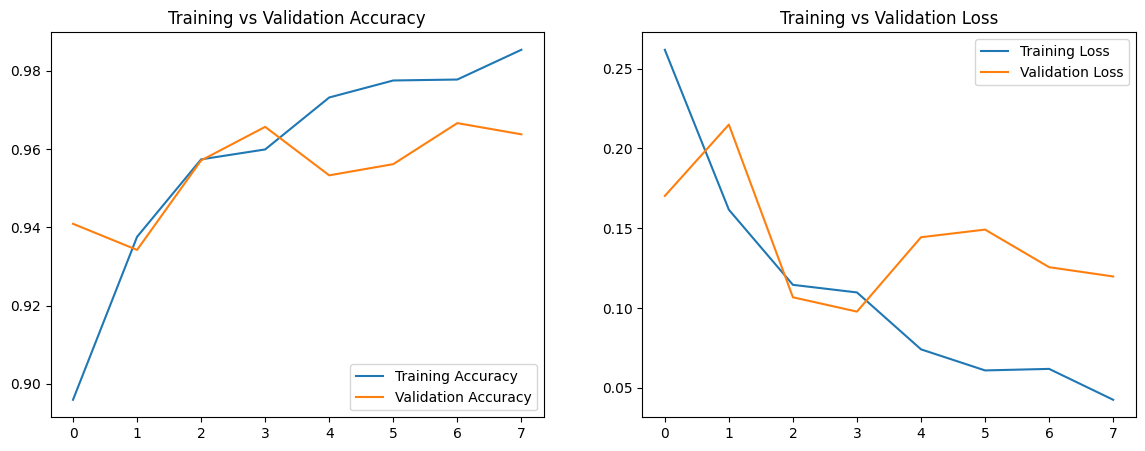

In [38]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# ===== 1. VISUALISASI =====
# Menggabungkan history1 dan history2 jika kamu mau, tapi di sini hanya history2
acc = history1.history['accuracy']
val_acc = history1.history['val_accuracy']
loss = history1.history['loss']
val_loss = history1.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training vs Validation Accuracy')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training vs Validation Loss')

plt.show()

c:\Users\Bisma\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


33/33 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step
=== Classification Report ===
              precision    recall  f1-score   support

   Anorganik       0.98      0.94      0.96       567
     Organik       0.93      0.98      0.95       462

    accuracy                           0.96      1029
   macro avg       0.96      0.96      0.96      1029
weighted avg       0.96      0.96      0.96      1029



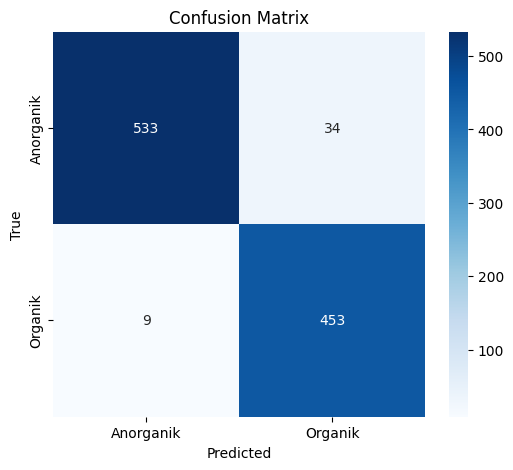

In [39]:
# Ambil prediksi model
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Classification Report
print("=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=class_labels))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# **5. Konversi Model**

In [40]:
model.save("model_organik_anorganik.h5")

In [41]:
from IPython.display import FileLink
FileLink('model_organik_anorganik.h5')  # klik link yang muncul untuk download

c:\Users\Bisma\Downloads\model_organik_anorganik.h5

In [42]:
!pip install tf2onnx


  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
mlflow-skinny 3.8.0 requires packaging<26, but you have packaging 26.2 which is incompatible.
streamlit 1.50.0 requires packaging<26,>=20, but you have packaging 26.2 which is incompatible.
tensorflowjs 3.18.0 requires packaging~=20.9, but you have packaging 26.2 which is incompatible.

[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/839.1 kB ? eta -:--:--
   ------------------------ --------------- 524.3/839.1 kB 4.9 MB/s eta 0:00:01
   ---------------------------------------- 839.1/839.1 kB 2.5 MB/s  0:00:00
   ---------------------------------------- 0.0/17.2 MB ? eta -:--:--
    --------------------------------------- 0.3/17.2 MB ? eta -:--:--
   - -------------------------------------- 0.8/17.2 MB 2.2 MB/s eta 0:00:08
   --- ------------------------------------ 1.3/17.2 MB 2.1 MB/s eta 0:00:08
   --- ------------------------------------ 1.6/17.2 MB 1.8 MB/s eta 0:00:09
   ---- ----------------------------------- 2.1/17.2 MB 1.8 MB/s eta 0:00:09
   ---- ----------------------------------- 2.1/17.2 MB 1.8 MB/s eta 0:00:09
   ----- ---------------------------------- 2.4/17.2 MB 1.6 MB/s eta 0:00:10
   ------- -------------------------------- 3.1/17.2 MB 1.9 MB/s eta 0:00:08
   --------- ------------------------------ 3.9/17.2 MB 2.0 MB/s eta 0:00:07
   ---------- --

In [44]:
import tensorflow as tf
import tf2onnx
import os

# Tentukan nama file output Anda
H5_FILENAME = "model_organik_anorganik.h5"
ONNX_FILENAME = "model_organik_anorganik.onnx"

print(f"\nMenyimpan model ke format H5: {H5_FILENAME}...")
model.save(H5_FILENAME)
print(f"Model H5 berhasil disimpan.")

# Spesifikasi input untuk konverter ONNX. Kita ambil langsung dari model.
input_signature = [tf.TensorSpec(model.inputs[0].shape, model.inputs[0].dtype, name=model.inputs[0].name)]

print(f"\nMengonversi model dari H5 ke format ONNX: {ONNX_FILENAME}...")
print(f"Spesifikasi Input yang digunakan: {input_signature}")

# Jalankan konversi dengan opset 13
model_proto, _ = tf2onnx.convert.from_keras(model, input_signature, opset=13)

# Simpan model ONNX ke file
with open(ONNX_FILENAME, "wb") as f:
    f.write(model_proto.SerializeToString())

print(f"Model ONNX berhasil dibuat dan disimpan sebagai '{ONNX_FILENAME}'.")

# ================================================================
# Verifikasi File di Direktori Lokal (Windows)
# ================================================================
print("\nFile yang ada di direktori kerja saat ini:")
!dir

print("\n--- PROSES SELESAI ---")
print(f"✅✅✅ Silakan cari file '{ONNX_FILENAME}' di folder proyek/direktori aktif Anda.")


Menyimpan model ke format H5: model_organik_anorganik.h5...
Model H5 berhasil disimpan.

Mengonversi model dari H5 ke format ONNX: model_organik_anorganik.onnx...
Spesifikasi Input yang digunakan: [TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='gambar_input')]



Model ONNX berhasil dibuat dan disimpan sebagai 'model_organik_anorganik.onnx'.

File yang ada di direktori kerja saat ini:
 Volume in drive C is Windows-SSD
 Volume Serial Number is B426-F549

 Directory of c:\Users\Bisma\Downloads

21/07/2026  00:18    <DIR>          .
29/06/2026  20:41    <DIR>          ..
11/02/2024  23:33         1.005.966 #BNSP I KADEK BISMA YOGA.pdf
13/02/2026  02:38        10.328.172 #CelcomDigiSecure _ The Network That Keeps You Secure.mp4
21/07/2024  12:11         4.006.913 (1) Pamflet Webnas.png
05/11/2023  09:16    <DIR>          (DRIVER ARDUINO) CH34x (1)
05/11/2023  09:16           193.607 (DRIVER ARDUINO) CH34x (1).zip
12/10/2023  14:25           193.607 (DRIVER ARDUINO) CH34x.zip
13/09/2025  16:36        12.334.062 (SD2025030000469)_Infografis.png
12/09/2025  15:30           522.645 (SD2025030000469)_Orisinalitas.pdf
11/01/2024  14:59    <DIR>          ,usic
06/03/2024  17:53            46.769 -BDOCselQruQzgrHpeK7Ew_3fc880b095f84ee4863332837ef2d8f1_DAC1

In [46]:
# Memuat kembali model yang sudah disimpan sebelumnya
H5_FILENAME = "model_organik_anorganik.h5"
loaded_model = tf.keras.models.load_model(H5_FILENAME)
print("Model berhasil dimuat ulang ke variabel 'loaded_model'!")

Model berhasil dimuat ulang ke variabel 'loaded_model'!


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step


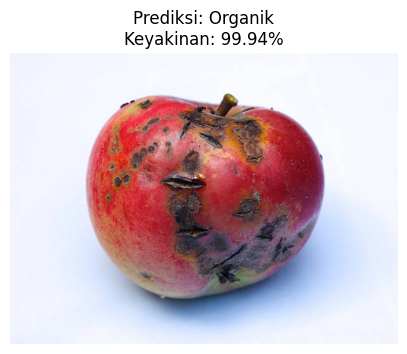


 Hasil Pengujian Gambar:
- File Gambar    : istockphoto-179349587-612x612.jpg
- Prediksi Kelas : Organik
- Akurasi/Conf   : 99.94%


In [52]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import os

# 1. Masukkan path gambar yang ingin Anda tes di sini (contoh: 'C:/Users/Bisma/Pictures/sampah_plastik.jpg')
# Pastikan menggunakan awalan r atau garis miring (/) agar tidak error di Windows
path_gambar_uji = r"C:\Users\Bisma\Downloads\istockphoto-179349587-612x612.jpg" 

# 2. Cek apakah file gambar tersedia
if os.path.exists(path_gambar_uji):
    # Load dan preprocess gambar (Resize ke 224x224 sesuai input model)
    img = image.load_img(path_gambar_uji, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # Tambah dimensi batch (1, 224, 224, 3)
    img_array = img_array / 255.0 # Normalisasi piksel

    # 3. Melakukan Prediksi menggunakan loaded_model
    predictions = loaded_model.predict(img_array)
    predicted_class_index = np.argmax(predictions[0])
    confidence = np.max(predictions[0]) * 100

    # Mendapatkan daftar nama kelas dari training generator
    class_labels = list(train_generator.class_indices.keys())
    predicted_label_name = class_labels[predicted_class_index]

    # 4. Menampilkan gambar dan hasil prediksinya
    plt.figure(figsize=(5, 5))
    plt.imshow(image.load_img(path_gambar_uji))
    plt.axis('off')
    plt.title(f"Prediksi: {predicted_label_name}\nKeyakinan: {confidence:.2f}%", fontsize=12)
    plt.show()

    print(f"\n Hasil Pengujian Gambar:")
    print(f"- File Gambar    : {os.path.basename(path_gambar_uji)}")
    print(f"- Prediksi Kelas : {predicted_label_name}")
    print(f"- Akurasi/Conf   : {confidence:.2f}%")
else:
    print(f"File gambar tidak ditemukan di path: {path_gambar_uji}")
    print("Silakan periksa kembali path atau nama file gambar Anda.")

In [53]:
import cv2
import numpy as np
import tensorflow as tf

# Pastikan model sudah dimuat (jika belum, jalankan baris di bawah)
# H5_FILENAME = "model_organik_anorganik.h5"
# loaded_model = tf.keras.models.load_model(H5_FILENAME)

# Membuka kamera web (0 adalah indeks default untuk kamera laptop)
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    print("Error: Tidak dapat membuka kamera.")
else:
    print("Kamera berhasil dibuka!")
    print("PETUNJUK:")
    print(" - Tekan tombol [SPACEBAR] / [SPASI] untuk mengambil foto dan mendeteksi.")
    print(" - Tekan tombol [ESC] atau [q] untuk keluar dari program.")

    class_labels = list(train_generator.class_indices.keys())

    while True:
        ret, frame = cap.read()
        if not ret:
            print("Gagal membaca frame dari kamera.")
            break

        # Tampilkan video live dari kamera di jendela baru
        cv2.imshow('Deteksi Sampah - Tekan SPASI untuk Ambil Foto', frame)

        # Menangkap tombol keyboard yang ditekan
        key = cv2.waitKey(1) & 0xFF

        # Jika tombol [ESC] atau 'q' ditekan, keluar dari loop
        if key == 27 or key == ord('q'):
            break

        # Jika tombol [SPACEBAR] ditekan (ASCII 32)
        elif key == 32:
            print("\n📸 Foto diambil! Sedang memproses prediksi...")

            # 1. Konversi warna dari BGR (OpenCV) ke RGB
            rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            # 2. Resize gambar ke 224x224 (sesuai input model)
            resized_img = cv2.resize(rgb_frame, (224, 224))

            # 3. Ubah ke array dan normalisasi
            img_array = resized_img.astype('float32') / 255.0
            img_array = np.expand_dims(img_array, axis=0)  # Tambah dimensi batch (1, 224, 224, 3)

            # 4. Melakukan Prediksi
            predictions = loaded_model.predict(img_array)
            predicted_class_index = np.argmax(predictions[0])
            confidence = np.max(predictions[0]) * 100
            predicted_label_name = class_labels[predicted_class_index]

            # 5. Cetak hasil prediksi di Console
            print(f"-> Prediksi Kelas : {predicted_label_name}")
            print(f"-> Tingkat Akurasi : {confidence:.2f}%\n")

            # 6. Tampilkan gambar yang ditangkap beserta teks hasil prediksinya menggunakan OpenCV
            hasil_display = frame.copy()
            text = f"{predicted_label_name} ({confidence:.1f}%)"
            cv2.putText(hasil_display, text, (30, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2, cv2.LINE_AA)
            
            cv2.imshow('Hasil Prediksi Sampah', hasil_display)

# Tutup kamera dan hancurkan jendela OpenCV setelah selesai
cap.release()
cv2.destroyAllWindows()
print("Kamera ditutup dan program selesai.")

Kamera berhasil dibuka!
PETUNJUK:
 - Tekan tombol [SPACEBAR] / [SPASI] untuk mengambil foto dan mendeteksi.
 - Tekan tombol [ESC] atau [q] untuk keluar dari program.

📸 Foto diambil! Sedang memproses prediksi...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step
-> Prediksi Kelas : Anorganik
-> Tingkat Akurasi : 99.91%


📸 Foto diambil! Sedang memproses prediksi...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
-> Prediksi Kelas : Anorganik
-> Tingkat Akurasi : 100.00%


📸 Foto diambil! Sedang memproses prediksi...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
-> Prediksi Kelas : Anorganik
-> Tingkat Akurasi : 99.26%


📸 Foto diambil! Sedang memproses prediksi...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
-> Prediksi Kelas : Anorganik
-> Tingkat Akurasi : 100.00%


📸 Foto diambil! Sedang memproses prediksi...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
-> Prediksi Kelas : Anorganik
-> Tingkat Akurasi : 99.56%


📸 Foto diambil! Sedang memproses prediksi...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
-> Prediksi Kelas : Anorgani

KeyboardInterrupt: 